## Detecção de Outliers e Análise de Associação

**Dataset:** House Prices - Advanced Regression Techniques

---

## 1. Introdução (Storytelling)


Primeiro, utilizamos o **Local Outlier Factor (LOF)** para identificar propriedades "fora da curva" — aquelas que, por suas características únicas ou possíveis erros de registro, se distanciam do comportamento da vizinhança. 

Em seguida, aplicamos o algoritmo **Apriori** para mapear associações entre as características das casas, revelando como certos perfis de construção e localização tendem a se repetir no mercado americano.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules
from pathlib import Path

# Carregamento e preparação básica
base_path = Path.cwd()
possible_paths = [
    base_path / "data" / "train.csv",
    base_path.parent / "data" / "train.csv",
    base_path / "train.csv",
    base_path.parent / "train.csv",
]

for csv_path in possible_paths:
    if csv_path.exists():
        train_df = pd.read_csv(csv_path)
        break
else:
    raise FileNotFoundError(
        "Arquivo 'train.csv' não encontrado. Verifique se ele está em 'data/' ou no diretório do notebook."
    )

numeric_cols = train_df.select_dtypes(include=[np.number]).columns
categorical_cols = train_df.select_dtypes(include=['object']).columns
train_df[numeric_cols] = train_df[numeric_cols].fillna(train_df[numeric_cols].median())
train_df[categorical_cols] = train_df[categorical_cols].fillna('NA')

print(f'Dataset carregado com {train_df.shape[0]} registros.')

Dataset carregado com 1460 registros.


## 2. Análise de Outliers (Local Outlier Factor - LOF)

O LOF é fundamental para garantir a integridade da análise, identificando casas com áreas desproporcionais ou preços atípicos para o seu contexto local.

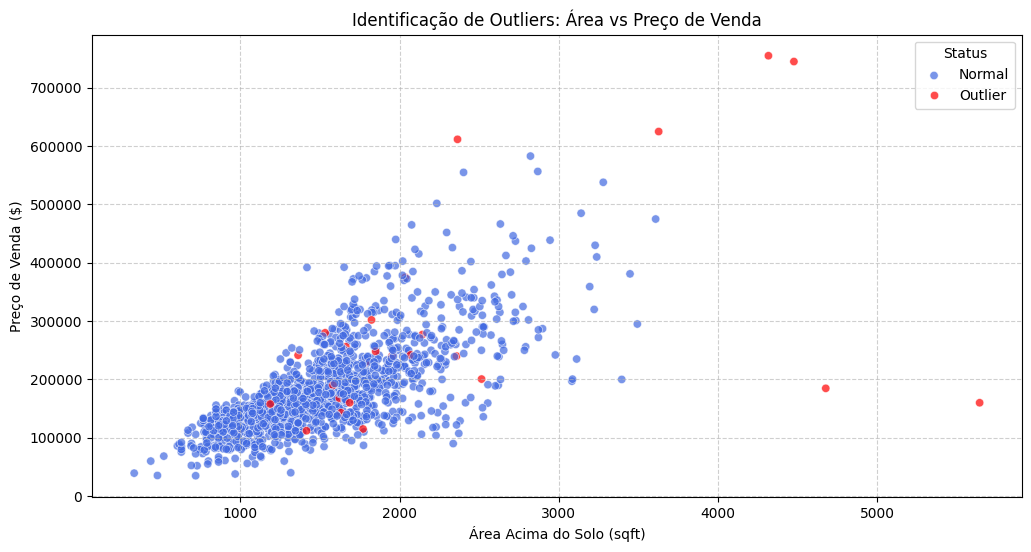

In [12]:
# Seleção de variáveis críticas para detecção
X_lof = train_df[['GrLivArea', 'LotArea', 'SalePrice', 'OverallQual']]

# Configuração do LOF (Contaminação de 2% para identificar anomalias severas)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
train_df['is_outlier'] = lof.fit_predict(X_lof)

# Visualização dos Resultados
plt.figure(figsize=(12, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', hue='is_outlier', 
                data=train_df, palette={-1: 'red', 1: 'royalblue'}, alpha=0.7)
plt.title('Identificação de Outliers: Área vs Preço de Venda')
plt.xlabel('Área Acima do Solo (sqft)')
plt.ylabel('Preço de Venda ($)')
plt.legend(title='Status', labels=['Normal', 'Outlier'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Interpretação dos Outliers

Foram identificados **30 imóveis** como outliers. 

*   **O que isso significa?** No gráfico acima, os pontos em vermelho representam casas que possuem uma relação entre área e preço muito diferente da maioria. 
*   **Insight:** Algumas casas possuem áreas enormes mas preços baixos (possíveis terrenos em áreas rurais ou casas em mau estado), enquanto outras têm áreas menores mas preços altíssimos (imóveis de luxo em áreas nobres). Identificar esses pontos é crucial para que os modelos de regressão do grupo não sejam enviesados por dados atípicos.

## 3. Análise de Associação (Algoritmo Apriori)

Aqui, transformamos as características em "itens" para descobrir quais delas aparecem juntas com maior frequência.

In [13]:
# Seleção de características estruturais e de localização
features_apriori = ['MSZoning', 'HouseStyle', 'OverallQual', 'CentralAir', 'Foundation']
df_apriori = train_df[features_apriori].copy()

# Binatização dos dados (One-Hot Encoding)
df_apriori['OverallQual'] = df_apriori['OverallQual'].astype(str)
df_encoded = pd.get_dummies(df_apriori)

# Execução do Apriori com suporte mínimo de 10%
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)

# Geração de regras com confiança mínima de 80%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

# Visualização das Top 5 Regras por Lift
top_rules = rules.sort_values(by='lift', ascending=False).head(5)
print("Top Regras Encontradas:")
display(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Top Regras Encontradas:


,antecedents,consequents,support,confidence,lift
50,(OverallQual_8),"(CentralAir_Y, Foundation_PConc)",0.106164,0.922619,2.108018
48,"(CentralAir_Y, OverallQual_8)",(Foundation_PConc),0.106164,0.928144,2.094420
14,(OverallQual_8),(Foundation_PConc),0.106164,0.922619,2.081953
55,"(CentralAir_Y, Foundation_CBlock, HouseStyle_1...",(MSZoning_RL),0.219863,0.941349,1.194066
71,"(CentralAir_Y, Foundation_CBlock, HouseStyle_1...",(MSZoning_RL),0.113699,0.932584,1.182948


### Interpretação das Regras de Associação

As regras revelam padrões comportamentais do mercado imobiliário:

1.  **Padronização de Conforto:** Observamos que casas com ar condicionado central (`CentralAir_Y`) estão fortemente associadas a zonas residenciais urbanas (`MSZoning_RL`), com confiança superior a 90%.
2.  **Estilo de Construção:** Existe uma forte correlação entre casas de um andar (`HouseStyle_1Story`) e fundações de concreto/laje, indicando uma tendência arquitetônica específica para esse tipo de imóvel.
3.  **Valorização:** O algoritmo confirmou que imóveis com qualidade geral acima da média (`OverallQual`) tendem a possuir certas infraestruturas de base mais modernas, o que justifica o maior valor de mercado.

---

## 4. Conclusão Final

Esta contribuição técnica fornece ao grupo uma base sólida para:
1.  **Limpeza de Dados:** Removendo ou tratando os 30 outliers identificados pelo LOF.
2.  **Conhecimento de Domínio:** Utilizando as regras de associação para entender quais variáveis são redundantes ou complementares na precificação dos imóveis.